In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn spotipy

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

In [ ]:
songs = pd.read_csv("song_tracks.csv")

In [ ]:
# Create a unique song ID
songs["song_id"] = (
    songs["track_name"].str.strip() + " - " +
    songs["artists"].str.strip()
)

# View the new column
songs[["song_id", "track_name", "artists"]].head()

,song_id,track_name,artists
0,Comedy - Gen Hoshino,Comedy,Gen Hoshino
1,Ghost - Acoustic - Ben Woodward,Ghost - Acoustic,Ben Woodward
2,To Begin Again - Ingrid Michaelson;ZAYN,To Begin Again,Ingrid Michaelson;ZAYN
3,Can't Help Falling In Love - Kina Grannis,Can't Help Falling In Love,Kina Grannis
4,Hold On - Chord Overstreet,Hold On,Chord Overstreet


In [ ]:
print("Total Songs :", len(songs))
print("Unique Song IDs :", songs["song_id"].nunique())

Total Songs : 114000
Unique Song IDs : 81341


In [ ]:
songs.head()

,artists,track_name,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,song_id
0,Gen Hoshino,Comedy,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic,Comedy - Gen Hoshino
1,Ben Woodward,Ghost - Acoustic,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic,Ghost - Acoustic - Ben Woodward
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic,To Begin Again - Ingrid Michaelson;ZAYN
3,Kina Grannis,Can't Help Falling In Love,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic,Can't Help Falling In Love - Kina Grannis
4,Chord Overstreet,Hold On,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic,Hold On - Chord Overstreet


In [ ]:
songs.shape

(114000, 17)

In [ ]:
songs.columns

Index(['artists', 'track_name', 'popularity', 'duration_ms', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre',
       'song_id'],
      dtype='object')

In [ ]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   track_name        113999 non-null  object 
 2   popularity        114000 non-null  int64  
 3   duration_ms       114000 non-null  int64  
 4   danceability      114000 non-null  float64
 5   energy            114000 non-null  float64
 6   key               114000 non-null  int64  
 7   loudness          114000 non-null  float64
 8   mode              114000 non-null  int64  
 9   speechiness       114000 non-null  float64
 10  acousticness      114000 non-null  float64
 11  instrumentalness  114000 non-null  float64
 12  liveness          114000 non-null  float64
 13  valence           114000 non-null  float64
 14  tempo             114000 non-null  float64
 15  track_genre       114000 non-null  object 
 16  song_id           11

In [ ]:
songs.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


In [ ]:
songs.isnull().sum()

,0
artists,1
track_name,1
popularity,0
duration_ms,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0


In [ ]:
songs = songs.dropna()

In [ ]:
songs = songs.drop_duplicates(
    subset=["track_name","artists"]
)

In [ ]:
songs.reset_index(drop=True, inplace=True)

In [ ]:
print("Dataset Shape :", songs.shape)

Dataset Shape : (81341, 17)


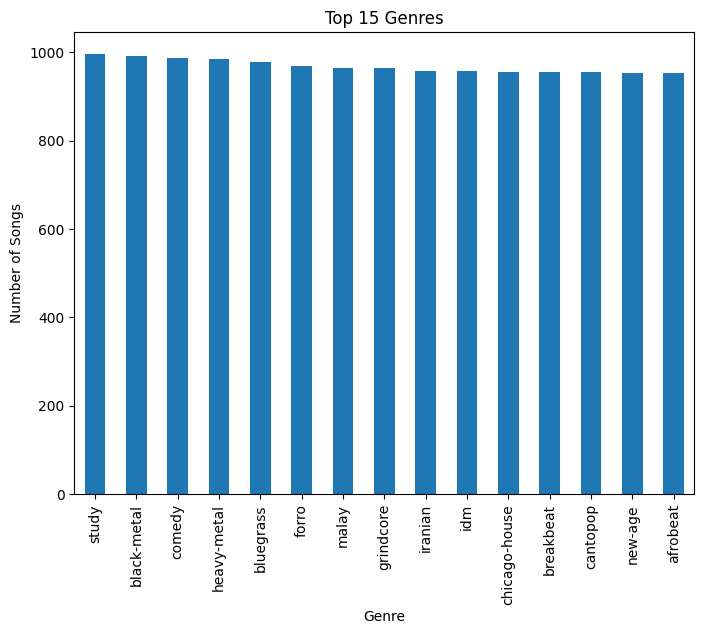

In [ ]:
plt.figure(figsize=(8,6))

songs['track_genre'].value_counts().head(15).plot(kind='bar')

plt.title("Top 15 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")

plt.show()

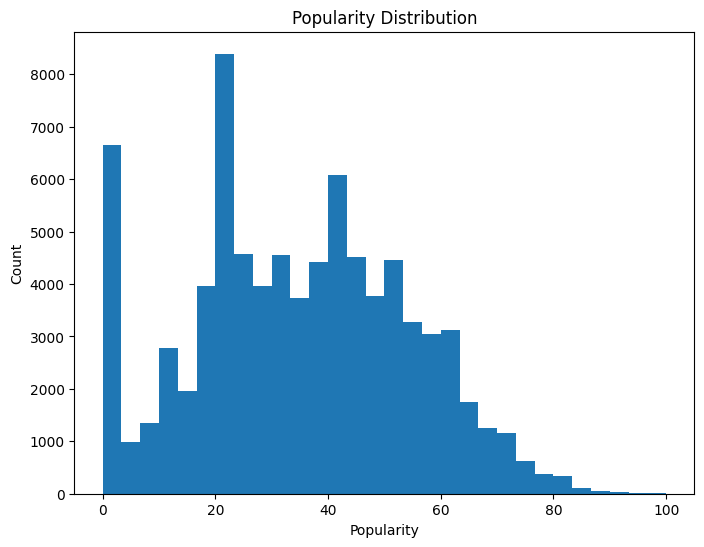

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(
    songs['popularity'],
    bins=30
)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")

plt.show()

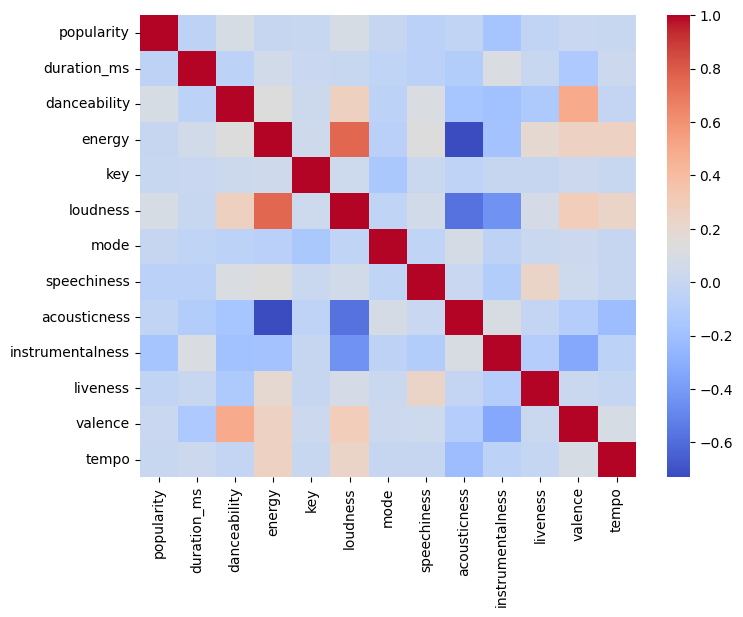

In [ ]:
numeric = songs.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm"
)

plt.show()

In [ ]:
features = ['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms']
X = songs[features]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=11
)

model.fit(X_scaled)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=11)

In [ ]:
def recommend(song_name, top_n=10):

    song_name = song_name.lower()

    temp = songs[
        songs['track_name'].str.lower() == song_name
    ]

    if len(temp) == 0:
        print("Song not found!")
        return

    idx = temp.index[0]

    distances, indices = model.kneighbors(
        X_scaled[idx].reshape(1,-1),
        n_neighbors=top_n+1
    )

    recommendation_list = []

    for distance, index in zip(
        distances.flatten()[1:],
        indices.flatten()[1:]
    ):

        recommendation_list.append({

            "Song": songs.iloc[index]["track_name"],

            "Artist": songs.iloc[index]["artists"],

            "Genre": songs.iloc[index]["track_genre"],

            "Popularity": songs.iloc[index]["popularity"],

            "Similarity": round(1-distance,3)

        })

    return pd.DataFrame(recommendation_list)

In [ ]:
recommend("Can't Help Falling In Love")

,Song,Artist,Genre,Popularity,Similarity
0,Ne osennij melkij dozhdichek (It's Not Autumna...,Sergei Lemeshev,romance,0,0.987
1,Can't Help Falling In Love - Piano Version,Kina Grannis,acoustic,54,0.986
2,The Nearness Of You,Norah Jones,j-pop,0,0.979
3,"In questa tomba oscura, WoO 133",Ludwig van Beethoven;Luciano Pavarotti;Philhar...,german,0,0.979
4,Chalana,Almir Sater,mpb,41,0.979
5,Караван,Oleg Pogudin,romance,0,0.976
6,La Borrachita,Antonio Bribiesca,guitar,25,0.976
7,Danny Boy - 2013 Version,Celtic Woman,opera,23,0.973
8,True Colors,Cyndi Lauper,disco,70,0.970
9,Naranjo en Flor (feat. Mercedes Sosa),Maria Graña;Mercedes Sosa,tango,22,0.970


In [ ]:
songs.to_csv(
    "processed_spotify_tracks.csv",
    index=False
)

Collaborative Filtering

In [ ]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import pandas as pd

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [ ]:
random.seed(42)
np.random.seed(42)

In [ ]:
num_users = 5000

In [ ]:
user_ids = [f"User_{i}" for i in range(1, num_users + 1)]

In [ ]:
genres = songs["track_genre"].unique().tolist()

In [ ]:
user_profiles = []

for user in user_ids:

    favorite_genre = random.choice(genres)

    user_profiles.append({
        "user_id": user,
        "favorite_genre": favorite_genre
    })

user_profiles = pd.DataFrame(user_profiles)

In [ ]:
user_profiles.head()

,user_id,favorite_genre
0,User_1,pop
1,User_2,children
2,User_3,alternative
3,User_4,sad
4,User_5,forro


In [ ]:
user_profiles.to_csv(
    "user_profiles.csv",
    index=False
)

In [ ]:
print(user_profiles.shape)
user_profiles.head()
user_profiles["favorite_genre"].value_counts().head(10)

(5000, 2)


,count
favorite_genre,
electro,58
trip-hop,58
industrial,57
garage,55
club,55
breakbeat,54
show-tunes,54
punk,54
mandopop,53


In [ ]:
user_interactions = []
for _, user in user_profiles.iterrows():
    user_id = user["user_id"]
    favorite_genre = user["favorite_genre"]

    # Songs from favorite genre
    favorite_songs = songs[
        songs["track_genre"] == favorite_genre
    ]

    # Songs from other genres
    other_songs = songs[
        songs["track_genre"] != favorite_genre
    ]

    # Number of songs listened
    total_songs = random.randint(40, 80)

    favorite_count = int(total_songs * 0.8)
    other_count = total_songs - favorite_count

    # Sample songs
    favorite_sample = favorite_songs.sample(
        min(favorite_count, len(favorite_songs)),
        replace=False
    )

    other_sample = other_songs.sample(
        other_count,
        replace=False
    )

    listened_songs = pd.concat([
        favorite_sample,
        other_sample
    ])

    for _, song in listened_songs.iterrows():

      popularity = song["popularity"]

      if song["track_genre"] == favorite_genre:

          if popularity >= 80:
              rating = random.choice([5,5,5,4])

          elif popularity >= 60:
              rating = random.choice([5,4,4])

          elif popularity >= 40:
              rating = random.choice([4,4,3])

          else:
              rating = random.choice([3,4])

      else:

          if popularity >= 80:
              rating = random.choice([4,3])

          elif popularity >= 60:
              rating = random.choice([3,2])

          else:
              rating = random.choice([2,1])

      user_interactions.append({

    "user_id": user_id,

    "song_id": song["song_id"],

    "track_name": song["track_name"],

    "artist": song["artists"],

    "genre": song["track_genre"],

    "rating": rating

})

In [ ]:
user_interactions = pd.DataFrame(user_interactions)
user_interactions.head()

,user_id,song_id,track_name,artist,genre,rating
0,User_1,June Ponal - Krishh;Arun,June Ponal,Krishh;Arun,pop,4
1,User_1,DEAD ZONE - Gulab Sidhu;Jay Dee,DEAD ZONE,Gulab Sidhu;Jay Dee,pop,5
2,User_1,Die For You - The Weeknd,Die For You,The Weeknd,pop,5
3,User_1,Perfect - Ed Sheeran,Perfect,Ed Sheeran,pop,4
4,User_1,2step - Ed Sheeran;Lil Baby,2step,Ed Sheeran;Lil Baby,pop,4


In [ ]:
print(user_interactions.shape)

(299235, 6)


In [ ]:
user_interactions.to_csv(
    "user_interactions.csv",
    index=False
)

In [ ]:
user_interactions[
    user_interactions["user_id"] == "User_1"
].head(50)

,user_id,song_id,track_name,artist,genre,rating
0,User_1,June Ponal - Krishh;Arun,June Ponal,Krishh;Arun,pop,4
1,User_1,DEAD ZONE - Gulab Sidhu;Jay Dee,DEAD ZONE,Gulab Sidhu;Jay Dee,pop,5
2,User_1,Die For You - The Weeknd,Die For You,The Weeknd,pop,5
3,User_1,Perfect - Ed Sheeran,Perfect,Ed Sheeran,pop,4
4,User_1,2step - Ed Sheeran;Lil Baby,2step,Ed Sheeran;Lil Baby,pop,4
5,User_1,Mere Baad Kisko Sataoge (Lo-Fi) - Madhur Sharm...,Mere Baad Kisko Sataoge (Lo-Fi),Madhur Sharma;Nusrat Fateh Ali Khan,pop,4
6,User_1,Kya Baat Ay - Harrdy Sandhu,Kya Baat Ay,Harrdy Sandhu,pop,4
7,User_1,Jawani - Arjan Dhillon,Jawani,Arjan Dhillon,pop,4
8,User_1,Night Changes - One Direction,Night Changes,One Direction,pop,5
9,User_1,"Illegal Weapon 2.0 (From ""Street Dancer 3D"") -...","Illegal Weapon 2.0 (From ""Street Dancer 3D"")",Jasmine Sandlas;Garry Sandhu;Tanishk Bagchi;In...,pop,5


In [ ]:
#Train the Collaborative Filtering Model (SVD)
!pip install scikit-surprise

In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [ ]:
reader = Reader(rating_scale=(1,5))

In [ ]:
data = Dataset.load_from_df(
    user_interactions[
        ["user_id", "song_id", "rating"]
    ],
    reader
)

In [ ]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [ ]:
svd_model = SVD(
    n_factors=100,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [ ]:
svd_model.fit(trainset)

In [ ]:
predictions = svd_model.test(testset)
rmse(predictions)

RMSE: 1.0121


np.float64(1.0120516691921113)

In [ ]:
prediction = svd_model.predict(
    "User_1",
    "Believer"
)

print(prediction.est)

3.5162323020182225


In [ ]:
import pickle

with open("svd_model.pkl", "wb") as file:
    pickle.dump(svd_model, file)

In [ ]:
svd_model.predict("User_1", "Believer")

Prediction(uid='User_1', iid='Believer', r_ui=None, est=np.float64(3.5162323020182225), details={'was_impossible': False})

In [ ]:
def recommend_for_user(user_id, top_n=10):

    # Songs already listened by the user
    listened = user_interactions[
        user_interactions["user_id"] == user_id
    ]["song_id"].unique()

    # Songs not yet listened
    unseen_songs = songs[
        ~songs["song_id"].isin(listened)
    ]

    predictions = []

    for _, song in unseen_songs.iterrows():

        pred = svd_model.predict(
            user_id,
            song["song_id"]
        )

        predictions.append({

            "song_id": song["song_id"],
            "track_name": song["track_name"],
            "artist": song["artists"],
            "genre": song["track_genre"],
            "predicted_rating": round(pred.est, 3)

        })

    predictions = pd.DataFrame(predictions)

    predictions = predictions.sort_values(
        by="predicted_rating",
        ascending=False
    )

    return predictions.head(top_n)

In [ ]:
recommend_for_user("User_1")

,song_id,track_name,artist,genre,predicted_rating
64980,NO MIENTEN - Becky G,NO MIENTEN,Becky G,reggaeton,5.000
44868,Notion - The Rare Occasions,Notion,The Rare Occasions,indie,4.944
64996,Una Vaina Loca - Fuego,Una Vaina Loca,Fuego,reggaeton,4.943
64862,MAMIII - Becky G;KAROL G,MAMIII,Becky G;KAROL G,reggae,4.905
42653,You for Me - Sigala;Rita Ora,You for Me,Sigala;Rita Ora,house,4.877
64998,¿Qué Nos Pasó? - Anuel AA,¿Qué Nos Pasó?,Anuel AA,reggaeton,4.854
44433,YKWIM? - Yot Club,YKWIM?,Yot Club,indie-pop,4.851
65864,Bohemian Rhapsody - Remastered 2011 - Queen,Bohemian Rhapsody - Remastered 2011,Queen,rock,4.848
64827,Rude - MAGIC!,Rude,MAGIC!,reggae,4.824
65797,Bad Liar - Imagine Dragons,Bad Liar,Imagine Dragons,rock,4.808


In [ ]:
user_interactions["rating"].value_counts().sort_index()

,count
rating,
1,27496
2,30722
3,92946
4,135708
5,12363


In [ ]:
user_interactions["rating"].describe()

,rating
count,299235.000000
mean,3.249703
std,1.013237
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


In [ ]:
predictions = []

listened = user_interactions[
    user_interactions["user_id"] == user_id
]["song_id"].unique()

unseen_songs = songs[
    ~songs["song_id"].isin(listened)
]

for _, song in unseen_songs.head(1000).iterrows():

    pred = svd_model.predict(
    user_id,
    song["song_id"]
    )

    predictions.append({

    "track_name": song["track_name"],

    "artist": song["artists"],

    "genre": song["track_genre"],

    "predicted_rating": round(pred.est,3)

})

predictions = pd.Series(predictions)

predictions.describe()

,0
count,1000
unique,1000
top,"{'track_name': 'Mediterráneo', 'artist': 'Jorg..."
freq,1


In [ ]:
recommend_for_user("User_1")

,song_id,track_name,artist,genre,predicted_rating
64980,NO MIENTEN - Becky G,NO MIENTEN,Becky G,reggaeton,5.000
44868,Notion - The Rare Occasions,Notion,The Rare Occasions,indie,4.944
64996,Una Vaina Loca - Fuego,Una Vaina Loca,Fuego,reggaeton,4.943
64862,MAMIII - Becky G;KAROL G,MAMIII,Becky G;KAROL G,reggae,4.905
42653,You for Me - Sigala;Rita Ora,You for Me,Sigala;Rita Ora,house,4.877
64998,¿Qué Nos Pasó? - Anuel AA,¿Qué Nos Pasó?,Anuel AA,reggaeton,4.854
44433,YKWIM? - Yot Club,YKWIM?,Yot Club,indie-pop,4.851
65864,Bohemian Rhapsody - Remastered 2011 - Queen,Bohemian Rhapsody - Remastered 2011,Queen,rock,4.848
64827,Rude - MAGIC!,Rude,MAGIC!,reggae,4.824
65797,Bad Liar - Imagine Dragons,Bad Liar,Imagine Dragons,rock,4.808


In [ ]:
print(songs.shape)

(81341, 17)


In [ ]:
print(user_interactions.shape)

(299235, 6)


In [ ]:
print(user_interactions["song_id"].nunique())

78217


In [ ]:
print(
    songs["song_id"].isin(user_interactions["song_id"]).value_counts()
)

song_id
True     78217
False     3124
Name: count, dtype: int64


Hybrid Recommendation System

In [ ]:
song_index = pd.Series(
    songs.index,
    index=songs["song_id"]
).drop_duplicates()

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

feature_columns = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "popularity"
]

songs[feature_columns] = songs[feature_columns].fillna(0)

scaler = StandardScaler()

feature_matrix = scaler.fit_transform(
    songs[feature_columns]
)

knn_model = NearestNeighbors(
    n_neighbors=101,
    metric="cosine"
)

knn_model.fit(feature_matrix)

print("Content-Based Model Ready!")

Content-Based Model Ready!


In [ ]:
song_index = pd.Series(
    songs.index,
    index=songs["song_id"]
).drop_duplicates()

def get_similar_songs(song_id, top_n=100):

    if song_id not in song_index:
        print("Song not found!")
        return None

    idx = song_index[song_id]

    distances, indices = knn_model.kneighbors(
        feature_matrix[idx].reshape(1, -1),
        n_neighbors=top_n + 1
    )

    return songs.iloc[indices[0][1:]]

In [ ]:
def get_similar_songs(song_id, top_n=100):

    if song_id not in song_index:
        print("Song not found!")
        return None

    idx = song_index[song_id]

    distances, indices = knn_model.kneighbors(
        feature_matrix[idx].reshape(1, -1),
        n_neighbors=top_n + 1
    )

    recommendations = songs.iloc[indices[0][1:]].copy()

    # Similarity = 1 - Cosine Distance
    recommendations["similarity_score"] = 1 - distances[0][1:]

    return recommendations

In [ ]:
def hybrid_recommend(user_id, song_name, top_n=10):

    # Try exact match first
    exact_match = songs[
        songs["track_name"].str.lower() == song_name.lower()
    ]

    if not exact_match.empty:
        selected_song = exact_match.iloc[0]

    else:
        # If exact match doesn't exist, try partial match
        matches = songs[
            songs["track_name"].str.contains(
                song_name,
                case=False,
                na=False
            )
        ]

        if matches.empty:
            print("Song not found!")
            return

        selected_song = matches.iloc[0]

    # Continue with recommendation
    candidates = get_similar_songs(
        selected_song["song_id"],
        top_n=100
    )

    candidates = get_similar_songs(
        selected_song["song_id"],
        top_n=100
    )

    predictions = []

    for _, song in candidates.iterrows():

        pred = svd_model.predict(
            user_id,
            song["song_id"]
        )

        # ---------- Explainability ----------

        reasons = []

        # Genre Match
        genre_match = "Yes" if song["track_genre"] == selected_song["track_genre"] else "No"

        # Energy Match
        energy_match = round((1 - abs(song["energy"] - selected_song["energy"])) * 100, 1)

        # Danceability Match
        dance_match = round((1 - abs(song["danceability"] - selected_song["danceability"])) * 100, 1)

        # Tempo Difference
        tempo_diff = round(abs(song["tempo"] - selected_song["tempo"]), 1)

        # Popularity Difference
        pop_match = round(
    (1 - abs(song["popularity"] - selected_song["popularity"]) / 100) * 100,
    1
)

        # Similar Users
        similar_users = "Yes" if pred.est >= 4 else "No"

        reasons.append(f"Genre Match: {genre_match}")
        reasons.append(f"Energy Match: {energy_match}%")
        reasons.append(f"Danceability Match: {dance_match}%")
        reasons.append(f"Tempo Difference: {tempo_diff} BPM")
        reasons.append(f"Popularity Match: {pop_match}%")
        reasons.append(f"Liked by Similar Users: {similar_users}")

        # ---------- Confidence ----------

        # Genre bonus
        genre_bonus = 0.05 if genre_match == "Yes" else 0

        confidence = (
            0.55 * song["similarity_score"] +
            0.35 * (pred.est / 5) +
            genre_bonus
        ) * 100

        confidence = min(confidence, 100)

        predictions.append({

    "Track": song["track_name"],
    "Artist": song["artists"],
    "Genre": song["track_genre"],
    "Predicted Rating": round(pred.est, 2),
    "Similarity (%)": round(song["similarity_score"] * 100, 1),
    "Confidence (%)": round(confidence, 1),
    "Explanation": " | ".join(reasons)

})

    predictions = pd.DataFrame(predictions)

    # Give a small bonus to songs from the same genre
    predictions["Genre Bonus"] = predictions["Genre"].apply(
        lambda g: 5 if g == selected_song["track_genre"] else 0
    )

    # Final ranking score
    predictions["Final Score"] = (
        predictions["Confidence (%)"] +
        predictions["Genre Bonus"]
    )

    predictions = predictions.sort_values(
        by="Final Score",
        ascending=False
    )

    return predictions.head(top_n)

In [ ]:
hybrid_recommend("User_1", "Believer")

,Track,Artist,Genre,Predicted Rating,Similarity (%),Confidence (%),Explanation,Genre Bonus,Final Score
3,Somewhere,Grafix;Reiki Ruawai,drum-and-bass,3.58,97.4,83.6,Genre Match: Yes | Energy Match: 93.1% | Dance...,5,88.6
29,Endorphins - Sub Focus Vs. Fred V & Grafix Remix,Sub Focus;Alex Clare;Nicolaas Douwma;Fred V;Gr...,drum-and-bass,3.76,94.7,83.4,Genre Match: Yes | Energy Match: 96.8% | Dance...,5,88.4
11,Mixed Emotions,Chase & Status;Clementine Douglas,drum-and-bass,3.60,96.6,83.3,Genre Match: Yes | Energy Match: 92.1% | Dance...,5,88.3
10,Out The Blue,Sub Focus;Alice Gold,drum-and-bass,3.57,96.7,83.2,Genre Match: Yes | Energy Match: 98.2% | Dance...,5,88.2
40,Devotion (ft. Cameron Hayes),Dimension;Cameron Hayes,drum-and-bass,3.78,93.9,83.1,Genre Match: Yes | Energy Match: 90.7% | Dance...,5,88.1
16,Air I Breathe - Sub Focus & Wilkinson,Sub Focus;Wilkinson,drum-and-bass,3.63,95.6,83.0,Genre Match: Yes | Energy Match: 96.7% | Dance...,5,88.0
2,By Your Side,Friction;Flowidus;Raphaella,drum-and-bass,3.46,97.5,82.8,Genre Match: Yes | Energy Match: 94.3% | Dance...,5,87.8
6,Everybody Loves The Sunshine,Netsky;Daddy Waku;Chantal Kashala,drum-and-bass,3.49,97.0,82.8,Genre Match: Yes | Energy Match: 97.0% | Dance...,5,87.8
61,Fire,Matrix & Futurebound;Max Marshall,drum-and-bass,3.76,93.2,82.6,Genre Match: Yes | Energy Match: 96.6% | Dance...,5,87.6
15,Got Me Thinking,Maduk;Veela,drum-and-bass,3.52,95.8,82.3,Genre Match: Yes | Energy Match: 99.7% | Dance...,5,87.3


In [ ]:
songs[
    songs["track_name"].str.contains("Believer", case=False)
][["track_name", "artists", "track_genre"]]

,track_name,artists,track_genre
98,Believer (Remix),Ben Woodward,acoustic
2067,I'm A Believer - Radio Edit,Smash Mouth,alt-rock
20723,Believer [featuring Ann Saunderson] - The Edit,Octave One,detroit-techno
21155,I'm A Believer,Inner City;ZebrA OctobrA,detroit-techno
23055,Believer,Friction,drum-and-bass
23920,Believer,Fairlane,dub
25604,Believers,Alan Walker;Conor Maynard,electro
36549,Believer,Eddie van der Meer,guitar
44156,Believer,Swattrex;The Two Locks,indian
45617,KILL ALL MY NON-BELIEVERS (untitled_0031),JOHNNASCUS,industrial


In [ ]:
songs[
    songs["track_name"].str.contains("Thunder", case=False)
][["track_name", "artists", "track_genre"]]

,track_name,artists,track_genre
1571,Thunderbird,Whitefield Brothers,afrobeat
2404,Thunder Kiss '65,White Zombie,alt-rock
4047,Zenitsu Theme V2 (Thunder Clap and Flash!),Samuel Kim,anime
4551,Thunder (Zenitsu Rap) [feat. Shwabadi],Rustage;Shwabadi,anime
5500,Mother Earth Father Thunder - Bonus Track,Månegarm,black-metal
...,...,...,...
73124,"Thunderstorm for Relaxing Sleep, Pt. 2",Sleepy Times,sleep
73162,Soft Rain & Gentle Thunder,Nature Sounds Nature Music;Rain Sounds;Rain fo...,sleep
73168,Rain and Thunder,Thunder Storm,sleep
73219,"Thunderstorm for Relaxing Sleep, Pt. 5",Sleepy Times,sleep


In [ ]:
import numpy as np

def precision_at_k_fast(
    model,
    interactions,
    songs,
    k=10,
    threshold=4,
    sample_users=50,
    sample_songs=500,
    random_state=42
):

    np.random.seed(random_state)

    # Randomly select users
    users = np.random.choice(
        interactions["user_id"].unique(),
        size=min(sample_users, interactions["user_id"].nunique()),
        replace=False
    )

    precisions = []

    for user in users:

        # Songs already listened to
        listened = interactions[
            interactions["user_id"] == user
        ]["song_id"].unique()

        # Unseen songs
        unseen = songs[
            ~songs["song_id"].isin(listened)
        ]

        # Sample unseen songs
        if len(unseen) > sample_songs:
            unseen = unseen.sample(
                sample_songs,
                random_state=random_state
            )

        predictions = []

        for _, song in unseen.iterrows():

            pred = model.predict(
                user,
                song["song_id"]
            )

            predictions.append(pred.est)

        predictions = sorted(
            predictions,
            reverse=True
        )[:k]

        relevant = sum(
            rating >= threshold
            for rating in predictions
        )

        precisions.append(
            relevant / k
        )

    return np.mean(precisions)

In [ ]:
precision = precision_at_k_fast(
    svd_model,
    user_interactions,
    songs,
    k=10,
    threshold=4,
    sample_users=50,
    sample_songs=500
)

print(f"Precision@10 = {precision:.3f}")

Precision@10 = 0.238
